# 02 · EDA — World Bank Indicators
Análisis exploratorio de indicadores económicos y de uso del suelo para Bolivia y Colombia.  
**Fuente:** World Bank Open Data API (`download_worldbank.py`)  
**Archivo:** `data/external/worldbank/worldbank_indicators.csv`

Indicadores:
- `gdp_usd` — PIB en USD corrientes
- `rural_population` — Población rural
- `agricultural_land_pct` — Tierra agrícola (% del territorio)
- `agri_exports_pct` — Exportaciones agrícolas (% del total)

## 0. Setup
Importa librerías y carga el CSV de indicadores del World Bank. Si no existe localmente, lo descarga ejecutando `download_worldbank.py`.

In [3]:
# ── Adquisición de datos: lectura local o descarga desde S3 vía Proxy ──
import os, requests
from pathlib import Path
try:
    from dotenv import load_dotenv
    load_dotenv(Path("..") / ".env")
except ImportError:
    pass

PROXY_URL = os.getenv("DATA_PROXY_URL", "https://docs.jhoanhurtado.com").rstrip("/")

def ensure_csv(proxy_rel_path: str, local_path: str):
    """Si el archivo local no existe, lo descarga desde S3 a través del proxy inverso."""
    local = Path(local_path)
    if local.exists() and local.stat().st_size > 0:
        print(f"✅ Archivo local listo: {local} ({local.stat().st_size/1e6:.1f} MB)")
        return
    
    url = f"{PROXY_URL}/{proxy_rel_path}"
    print(f"⬇ No encontrado localmente. Descargando desde S3 ({url})...")
    try:
        local.parent.mkdir(parents=True, exist_ok=True)
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(local, "wb") as f:
                for chunk in r.iter_content(chunk_size=1048576):
                    f.write(chunk)
        print(f"✅ Descarga exitosa: {local} ({local.stat().st_size/1e6:.1f} MB)")
    except Exception as e:
        print(f"⚠️ Error al descargar desde S3 proxy ({url}): {e}")
        if not local.exists():
            raise FileNotFoundError(f"❌ No se encontró el dataset en {local} ni se pudo descargar desde {url}.")

ensure_csv("deforestacion-alert-etl/external/worldbank/worldbank_indicators.csv", "../data/external/worldbank/worldbank_indicators.csv")


✅ Archivo local listo: ../data/external/worldbank/worldbank_indicators.csv (0.0 MB)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

WB_CSV = Path('../data/external/worldbank/worldbank_indicators.csv')
RES    = Path('../data/results'); RES.mkdir(parents=True, exist_ok=True)

if not WB_CSV.exists():
    raise FileNotFoundError(f'Ejecuta scripts/download_worldbank.py primero. Esperado: {WB_CSV}')

df = pd.read_csv(WB_CSV)
print(f'Filas: {len(df):,} | Columnas: {list(df.columns)}')
df.head()

Filas: 80 | Columnas: ['country_code', 'country_name', 'year', 'indicator_code', 'indicator_name', 'value']


,country_code,country_name,year,indicator_code,indicator_name,value
0,BOL,Bolivia,2024,NY.GDP.MKTP.CD,gdp_usd,5.488133e+10
1,BOL,Bolivia,2023,NY.GDP.MKTP.CD,gdp_usd,5.234021e+10
2,BOL,Bolivia,2022,NY.GDP.MKTP.CD,gdp_usd,5.095908e+10
3,BOL,Bolivia,2021,NY.GDP.MKTP.CD,gdp_usd,4.787789e+10
4,BOL,Bolivia,2020,NY.GDP.MKTP.CD,gdp_usd,4.231378e+10


## 1. Estructura y calidad
Revisa tipos de datos, nulos, indicadores disponibles y rango de años. Verifica que los 4 indicadores estén presentes para ambos países en el período 2015–2024.

In [5]:
print('Tipos de datos:')
print(df.dtypes)
print('\nNulos:')
print(df.isnull().sum())
print('\nIndicadores disponibles:')
print(df['indicator_name'].unique())
print('\nPaíses:')
print(df['country_code'].unique())
print('\nRango de años:')
print(df['year'].min(), '→', df['year'].max())

Tipos de datos:
country_code          str
country_name          str
year                int64
indicator_code        str
indicator_name        str
value             float64
dtype: object

Nulos:
country_code      0
country_name      0
year              0
indicator_code    0
indicator_name    0
value             0
dtype: int64

Indicadores disponibles:
<StringArray>
['gdp_usd', 'rural_population', 'agricultural_land_pct', 'agri_exports_pct']
Length: 4, dtype: str

Países:
<StringArray>
['BOL', 'COL']
Length: 2, dtype: str

Rango de años:
2015 → 2024


In [6]:
# Pivotear para ver todos los indicadores por país/año
pivot = df.pivot_table(index=['country_code', 'year'],
                       columns='indicator_name', values='value').reset_index()
print(f'Pivot shape: {pivot.shape}')
print('\nNulos en pivot:')
print(pivot.isnull().sum())
pivot.head(6)

Pivot shape: (20, 6)

Nulos en pivot:
indicator_name
country_code             0
year                     0
agri_exports_pct         0
agricultural_land_pct    0
gdp_usd                  0
rural_population         0
dtype: int64


indicator_name,country_code,year,agri_exports_pct,agricultural_land_pct,gdp_usd,rural_population
0,BOL,2015,0.515342,35.282009,3.300020e+10,3481109.0
1,BOL,2016,0.536267,35.154620,3.394113e+10,3494356.0
2,BOL,2017,0.488910,35.022616,4.592744e+10,3507315.0
3,BOL,2018,0.552690,35.263971,4.841404e+10,3520020.0
4,BOL,2019,0.500793,35.544411,4.905664e+10,3532520.0
5,BOL,2020,0.753499,35.564590,4.231378e+10,3539659.0


## 2. Tendencias por indicador
Grafica la evolución temporal de cada indicador (PIB, población rural, tierra agrícola, exportaciones agrícolas) para Bolivia y Colombia. Identifica tendencias que puedan correlacionar con la deforestación.

> **Decisión de transformación:** los indicadores se almacenarán en tabla `dim_economic_context` con granularidad país-año para cruzar con alertas agregadas por año.

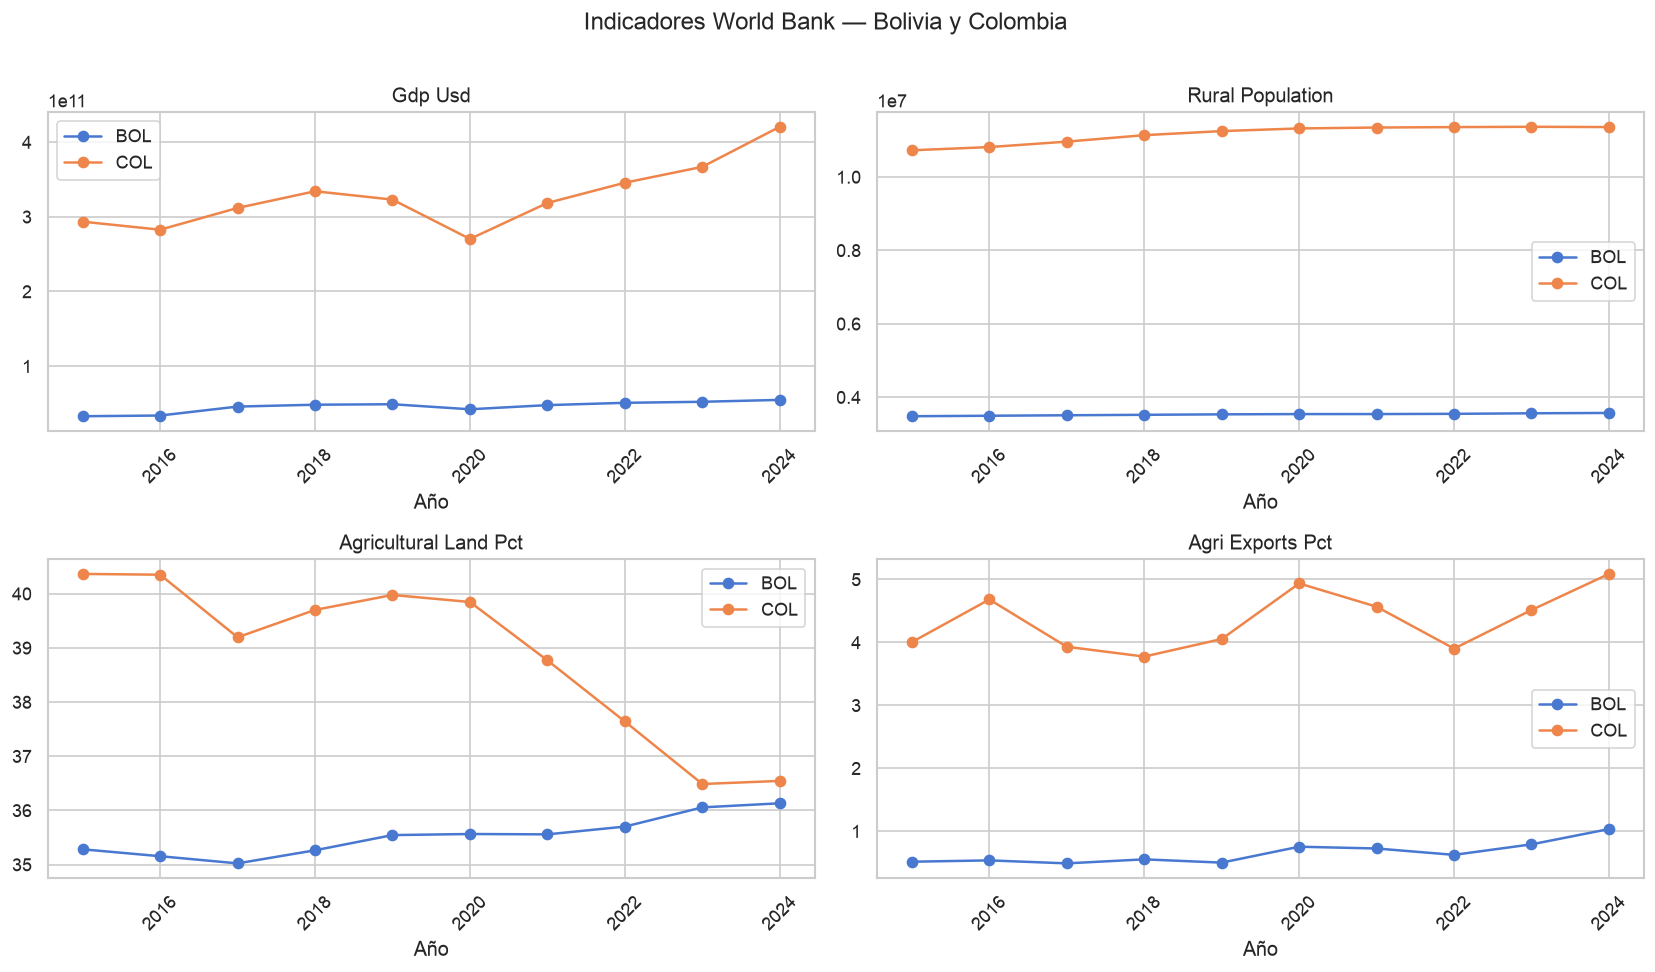

In [7]:
indicators = df['indicator_name'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, ind in zip(axes, indicators):
    for code_c, grp in df[df['indicator_name'] == ind].groupby('country_code'):
        grp_sorted = grp.sort_values('year')
        ax.plot(grp_sorted['year'], grp_sorted['value'], marker='o', label=code_c)
    ax.set_title(ind.replace('_', ' ').title())
    ax.set_xlabel('Año')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Indicadores World Bank — Bolivia y Colombia', y=1.01)
plt.tight_layout()
plt.savefig(RES / 'eda_worldbank_indicadores.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Correlación tierra agrícola vs alertas (preview)
Muestra la evolución de la tierra agrícola como porcentaje del territorio — el indicador más directamente relacionado con la expansión de la frontera agrícola sobre el bosque.

In [8]:
# Preview: tierra agrícola como proxy de presión sobre bosques
agri = df[df['indicator_name'] == 'agricultural_land_pct'].copy()
agri_pivot = agri.pivot(index='year', columns='country_code', values='value')
print('Tierra agrícola (% territorio) por año:')
print(agri_pivot.to_string())

Tierra agrícola (% territorio) por año:
country_code        BOL        COL
year                              
2015          35.282009  40.364489
2016          35.154620  40.350428
2017          35.022616  39.195133
2018          35.263971  39.700766
2019          35.544411  39.976566
2020          35.564590  39.846724
2021          35.557966  38.769112
2022          35.701418  37.641280
2023          36.055981  36.487607
2024          36.131324  36.544389


## 4. Hallazgos y decisiones de transformación
Tabla resumen de hallazgos del EDA y las decisiones de transformación que se aplicarán en el pipeline unificado.

| Hallazgo | Decisión |
|----------|----------|
| Datos anuales 2015–2024, sin nulos relevantes | Usar directamente para cruce con alertas por año |
| PIB y población rural tienen tendencia creciente en COL | Incluir como covariables en análisis de causalidad |
| Tierra agrícola estable en BOL (~35%), creciente en COL | Indicador clave para correlacionar con drivers de deforestación |
| Algunos años sin dato para `agri_exports_pct` | Imputar con interpolación lineal o excluir del modelo |

## Análisis extendido
Correlaciones entre indicadores (heatmap) y tendencias normalizadas con base 100 para comparar la evolución relativa de cada variable entre países.

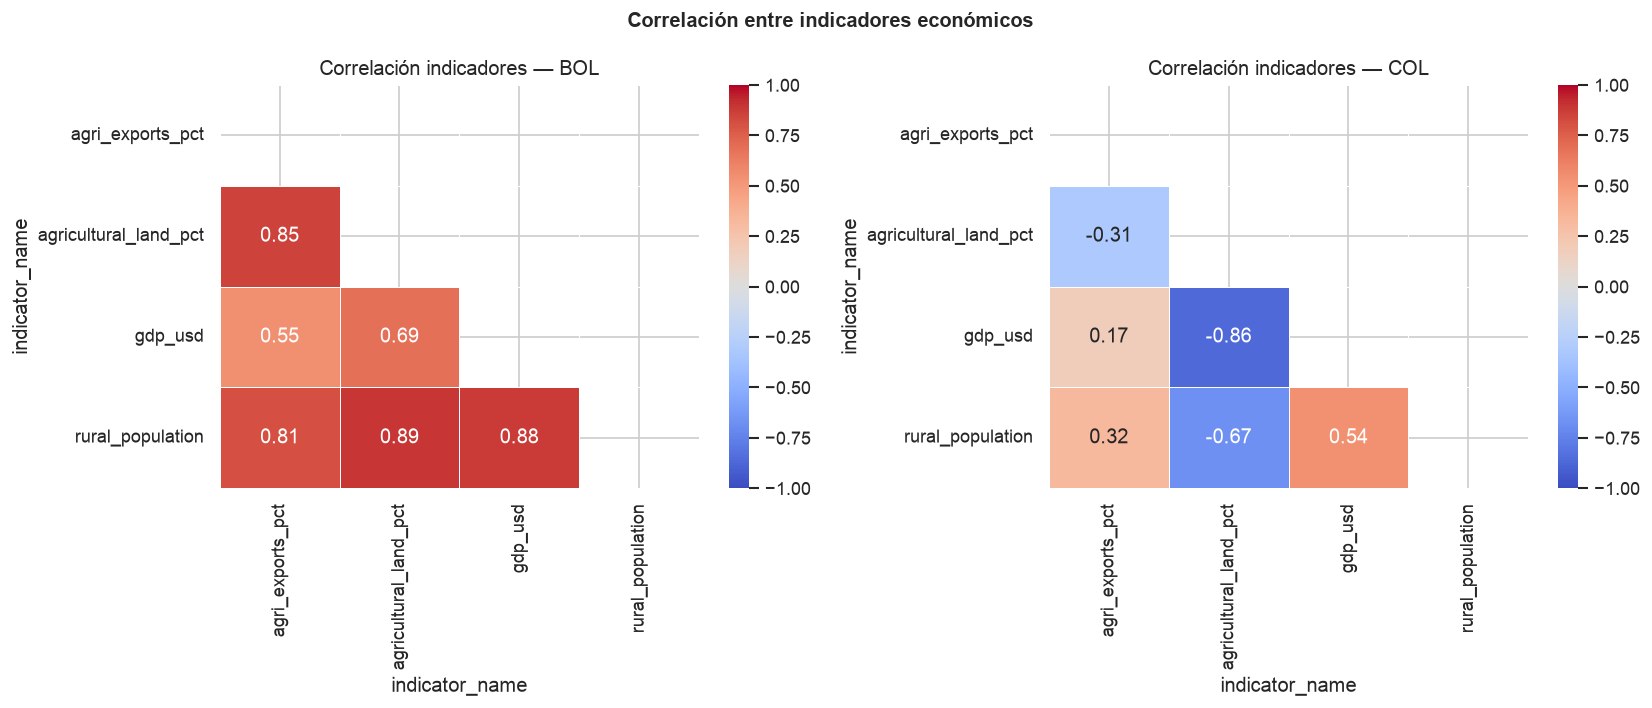

Guardado: eda_worldbank_extended.png


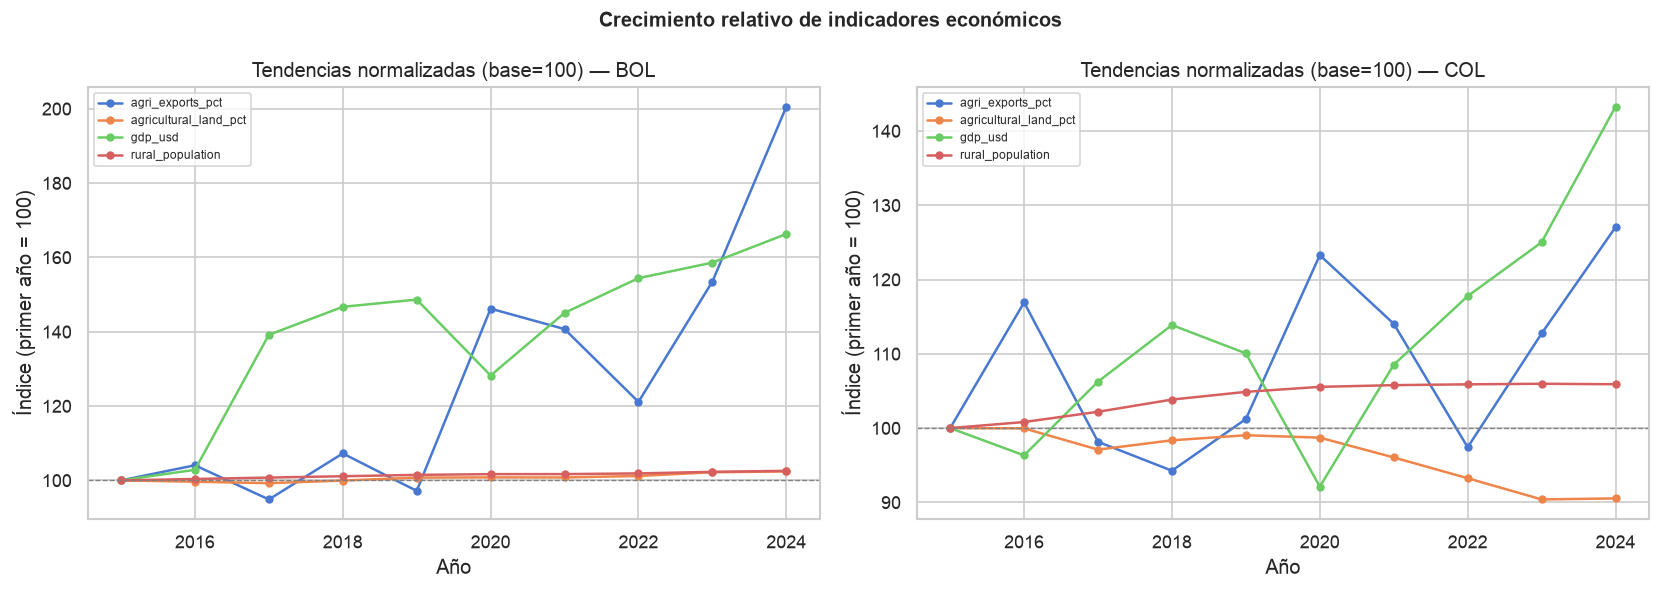

Guardado: eda_worldbank_tendencias_norm.png


In [9]:
# Análisis extendido WorldBank
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
RES = Path('../data/results')
RES.mkdir(parents=True, exist_ok=True)

wb_path_ext = Path('../data/external/worldbank/worldbank_indicators.csv')
if wb_path_ext.exists():
    wb_ext = pd.read_csv(wb_path_ext)
    # Si viene en formato largo, pivotear a formato ancho por indicador
    if 'indicator_name' in wb_ext.columns and 'value' in wb_ext.columns:
        wb_ext = wb_ext.pivot_table(index=['country_code', 'year'],
                                    columns='indicator_name', values='value').reset_index()

    wb_cols_ext = {c.lower(): c for c in wb_ext.columns}
    id_col_ext = next((v for k, v in wb_cols_ext.items() if 'country' in k and 'code' in k), None)
    year_col_ext = next((v for k, v in wb_cols_ext.items() if 'year' in k), None)
    ind_cols = [c for c in wb_ext.columns if c not in [id_col_ext, year_col_ext] and np.issubdtype(wb_ext[c].dtype, np.number)]
    if id_col_ext and year_col_ext and len(ind_cols) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        countries_wb = wb_ext[id_col_ext].unique()
        for ax, cc in zip(axes, countries_wb[:2]):
            sub_cc = wb_ext[wb_ext[id_col_ext] == cc].set_index(year_col_ext)[ind_cols]
            corr = sub_cc.corr()
            mask = np.triu(np.ones_like(corr, dtype=bool))
            sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                        mask=mask, vmin=-1, vmax=1, linewidths=0.5)
            ax.set_title(f'Correlación indicadores — {cc}')
        plt.suptitle('Correlación entre indicadores económicos', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(RES / 'eda_worldbank_extended.png', bbox_inches='tight')
        plt.show()
        print('Guardado: eda_worldbank_extended.png')
        # Tendencias normalizadas
        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
        for ax, cc in zip(axes2, countries_wb[:2]):
            sub_cc = wb_ext[wb_ext[id_col_ext] == cc].set_index(year_col_ext)[ind_cols].sort_index()
            norm = sub_cc.div(sub_cc.iloc[0]) * 100
            norm.plot(ax=ax, marker='o', ms=4)
            ax.axhline(100, linestyle='--', color='gray', linewidth=0.8)
            ax.set_title(f'Tendencias normalizadas (base=100) — {cc}')
            ax.set_xlabel('Año'); ax.set_ylabel('Índice (primer año = 100)')
            ax.legend(fontsize=7)
        plt.suptitle('Crecimiento relativo de indicadores económicos', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(RES / 'eda_worldbank_tendencias_norm.png', bbox_inches='tight')
        plt.show()
        print('Guardado: eda_worldbank_tendencias_norm.png')
else:
    print('⚠️ worldbank_indicators.csv no encontrado')
